In [72]:
import numpy as np
import tifffile as tiff
import imageio.v3 as iio
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from core.data import CompressionMetrics
from core.utils import make_dual_update, round_sig
from core.video3d import reconstruct_video3d, compress_video3d

In [ ]:
# ### Fluo-C3DH-A549_01 (lung cancer cell) ###
# video3d_raw = tiff.imread("sources/Fluo-C3DH-A549/01/*.tif")

# video3d_raw = np.pad(
#     video3d_raw,
#     pad_width=((0, 0), (0, 1), (0, 0), (0, 0)),
#     mode='constant',
#     constant_values=0
# )

# print(video3d_raw.shape)
# # (30, 30, 300, 350)

# nz, ny, nx = 100, 100, 100
# vid3d = video3d_raw[:, :, :, :]

In [220]:
video3d_raw = tiff.imread("sources/Fluo-N3DL-DRO/01/*.tif")

In [221]:
# True dimensions are (125, 603, 1272) - should crop to (120, 600, 1200)
nz, ny, nx = 100, 100, 100

# video3d_raw[:, :100, :100, :100] was all black; video3d_raw.min() == video3d_raw.max() == 0
# Below volume has actual data
vid3d = video3d_raw[:, :nz, 100:200, 400:500]

In [241]:
# Hyperparameters
poly_degrees = np.arange(2, 20, 1)
t_degree = 45
lp_degree = 2.0
block_size = 10
cutoff = None

params = {
        "t degree": t_degree,
        "lp degree": lp_degree,
        "Block size": block_size,
        "Cutoff": cutoff
    }

In [242]:
# Loop
metrics_list = []
video3d_rec_list = []
c_t_list = []
for poly_degree in poly_degrees:
    c_t, X_design, t_design_matrix, rescale = compress_video3d(
    vid3d,
    poly_degree=poly_degree,
    t_degree=t_degree,
    block_size=block_size,
    lp_degree=lp_degree,
    cutoff=cutoff
    )
    c_t = round_sig(c_t)
    #c_t = c_t.astype(np.float16)
    # Saving coefficients
    # np.save("results/video3d/drosophila_video_full_01/coefficients/coefficients__bs=%s__cutoff=%s__lp=%s__poly_deg=%s__t_degree=%s__dtype=%s.npy" %
    #         (block_size, cutoff, lp_degree, poly_degree, t_degree, c_t.dtype), c_t, allow_pickle=False)
    c_t_list.append(c_t)
    # print(c_t.dtype)
    video3d_rec = reconstruct_video3d(
        vid3d,
        block_size,
        c_t,
        X_design,
        t_design_matrix,
        rescale
    )
    metrics_list.append(CompressionMetrics(vid3d, video3d_rec, c_t))
    video3d_rec_list.append(video3d_rec)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done  64 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 2320 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 47690 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Done 50000 out of 50000 | elapsed:    3.2s finished


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 9200 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 50000 out of 50000 | elapsed:    1.5s finished


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 9200 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 50000 out of 50000 | elapsed:    1.7s finished


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 9200 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 50000 out of 50000 | elapsed:    1.8s finished


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 9200 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 50000 out of 50000 | elapsed:    1.6s finished


...

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 8688 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 40944 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 50000 out of 50000 | elapsed:    6.0s finished


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 6384 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 22512 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done 43248 tasks      | elapsed:    6.8s
[Parallel(n_jobs=-1)]: Done 50000 out of 50000 | elapsed:    7.8s finished


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 6384 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done 22512 tasks      | elapsed:    4.7s
[Parallel(n_jobs=-1)]: Done 43248 tasks      | elapsed:    8.8s
[Parallel(n_jobs=-1)]: Done 50000 out of 50000 | elapsed:   10.0s finished


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 6384 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done 22512 tasks      | elapsed:    5.7s
[Parallel(n_jobs=-1)]: Done 43248 tasks      | elapsed:   10.7s
[Parallel(n_jobs=-1)]: Done 50000 out of 50000 | elapsed:   12.2s finished


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 6384 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done 22512 tasks      | elapsed:    6.6s
[Parallel(n_jobs=-1)]: Done 43248 tasks      | elapsed:   12.4s
[Parallel(n_jobs=-1)]: Done 50000 out of 50000 | elapsed:   14.3s finished


In [243]:
# Extract values
psnr_values = [m.psnr for m in metrics_list]
ssim_values = [m.ssim for m in metrics_list]
compression_ratios = [m.compression_ratio for m in metrics_list]
space_saved_values = [m.space_saved for m in metrics_list]

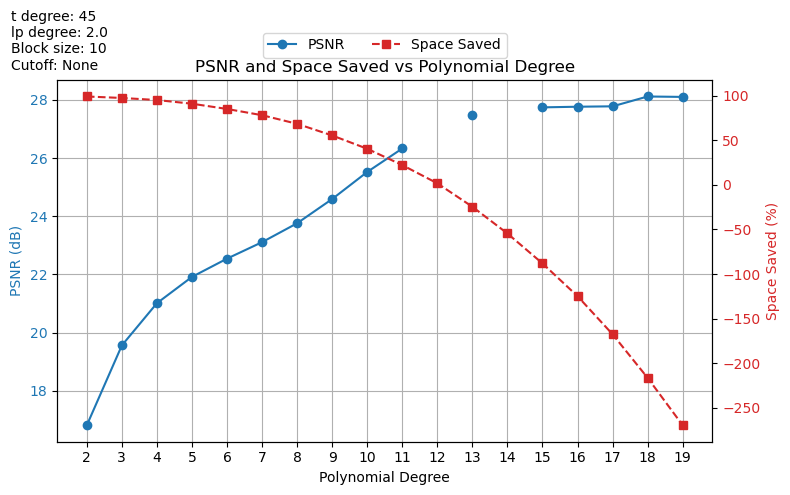

In [244]:
# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot PSNR on primary y-axis
ln1 = ax1.plot(poly_degrees, psnr_values, marker="o", linestyle="-", color="tab:blue", label="PSNR")
ax1.set_xlabel("Polynomial Degree")
ax1.set_ylabel("PSNR (dB)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True)
ax1.set_xticks(poly_degrees)

# Plot space saved on secondary y-axis
ax2 = ax1.twinx()
ln2 = ax2.plot(poly_degrees, space_saved_values, marker="s", linestyle="--", color="tab:red", label="Space Saved")
ax2.set_ylabel("Space Saved (%)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

# Combine legends and place outside top-left
lines = ln1 + ln2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=2)

plt.title("PSNR and Space Saved vs Polynomial Degree")

# To display other (fixed) params
param_text = "\n".join([f"{k}: {v}" for k, v in params.items()])

# Add text in figure coordinates (top-left)
fig.text(
    0.02, 0.98, # x, y in figure coords
    param_text,
    ha='left', va='top',
    fontsize=10,
     bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
)

fig.subplots_adjust(top=1.07)

plt.tight_layout()
plt.savefig("results/video3d/drosophila_video_full_01/plots/psnr_plots/psnr__pinv__bs=%s__cutoff=%s__lp=%s__poly_degree=%s-%s__t_degree=%s__dtype=%s.png" % 
            (block_size, cutoff, lp_degree, poly_degrees[0], poly_degrees[-1], t_degree, c_t_list[0].dtype))
plt.show()

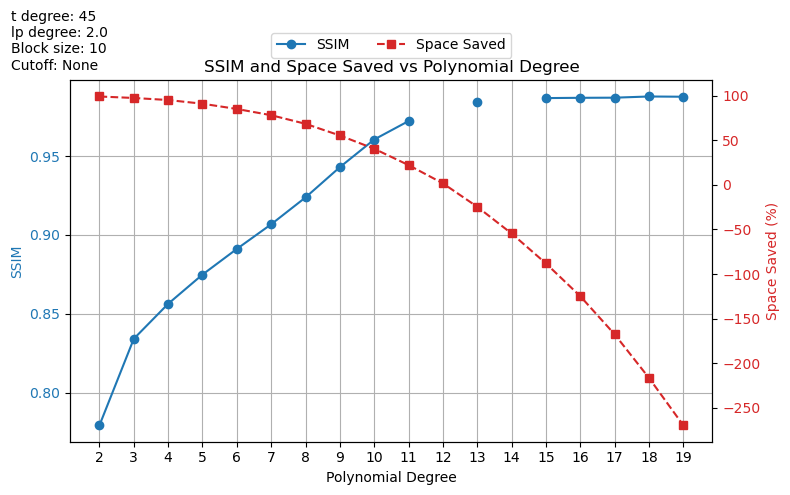

In [245]:
# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot SSIM on primary y-axis
ln1 = ax1.plot(poly_degrees, ssim_values, marker="o", linestyle="-", color="tab:blue", label="SSIM")
ax1.set_xlabel("Polynomial Degree")
ax1.set_ylabel("SSIM", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True)
ax1.set_xticks(poly_degrees)

# Plot space saved on secondary y-axis
ax2 = ax1.twinx()
ln2 = ax2.plot(poly_degrees, space_saved_values, marker="s", linestyle="--", color="tab:red", label="Space Saved")
ax2.set_ylabel("Space Saved (%)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

# Combine legends and place outside top-left
lines = ln1 + ln2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=2)

plt.title("SSIM and Space Saved vs Polynomial Degree")

# To display other (fixed) params
param_text = "\n".join([f"{k}: {v}" for k, v in params.items()])

# Add text in figure coordinates (top-left)
fig.text(
    0.02, 0.98, # x, y in figure coords
    param_text,
    ha='left', va='top',
    fontsize=10,
     bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
)

fig.subplots_adjust(top=1.07)

plt.tight_layout()
plt.savefig("results/video3d/drosophila_video_full_01/plots/psnr_plots/ssim__bs=%s__cutoff=%s__lp=%s__poly_degree=%s-%s__t_degree=%s__dtype=%s.png" % 
            (block_size, cutoff, lp_degree, poly_degrees[0], poly_degrees[-1], t_degree, c_t_list[0].dtype))
plt.show()